In [2]:
"""Problem Statement
Netflix wants to compare viewer engagement between:
Movies
TV Shows"""


'Problem Statement\nNetflix wants to compare viewer engagement between:\nMovies\nTV Shows'

In [3]:
# Data Processing & Manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Data Analysis & Statistics
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, levene, shapiro, zscore
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


import matplotlib.pyplot as plt
import seaborn as sns

# Visualization - Interactive
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Utilities
import warnings
import os
from pathlib import Path


print(" All libraries imported successfully!")
print(f" Analysis Environment Ready - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 All libraries imported successfully!
 Analysis Environment Ready - 2026-05-28 23:08:22


In [4]:
net_df = pd.read_csv(r"C:\Users\Lenovo\Documents\DE\Week1\DAY 1\stradit-internship\week2\day4\data\netflix_titles.csv")

print(net_df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
print(f"\n Dataset Shape: {net_df.shape[0]} rows × {net_df.shape[1]} columns")
print(f"Memory Usage: {net_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(net_df.info())


 Dataset Shape: 8807 rows × 12 columns
Memory Usage: 7.79 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [6]:
for i, col in enumerate(net_df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n Data Loading Complete.")

 1. show_id
 2. type
 3. title
 4. director
 5. cast
 6. country
 7. date_added
 8. release_year
 9. rating
10. duration
11. listed_in
12. description

 Data Loading Complete.


In [7]:
# Dataset dimensions
print(f"\nDATASET DIMENSIONS:")
print(f"   • Total Rows: {net_df.shape[0]:,}")
print(f"   • Total Columns: {net_df.shape[1]}")
print(f"   • Total Cells: {net_df.shape[0] * net_df.shape[1]:,}")

print()
# Data types overview
print(f"\n DATA TYPES OVERVIEW:")
dtype_counts = net_df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   • {dtype}: {count} columns")


DATASET DIMENSIONS:
   • Total Rows: 8,807
   • Total Columns: 12
   • Total Cells: 105,684


 DATA TYPES OVERVIEW:
   • object: 11 columns
   • int64: 1 columns


In [8]:
# Date range
print(f"\n TEMPORAL COVERAGE:")
net_df['Date'] = pd.to_datetime(net_df['date_added'], errors='coerce')
print(f"   • Start Date: {net_df['Date'].min().strftime('%Y-%m-%d')}")
print(f"   • End Date: {net_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   • Days Covered: {(net_df['Date'].max() - net_df['Date'].min()).days} days")
print(f"   • Unique Dates: {net_df['Date'].nunique()}")


 TEMPORAL COVERAGE:
   • Start Date: 2008-01-01
   • End Date: 2021-09-25
   • Days Covered: 5016 days
   • Unique Dates: 1699


In [9]:
print(f"\nNumeric Columns: {net_df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical Columns: {net_df.select_dtypes(include=['object']).columns.tolist()}")

print("\n Structure analysis complete!")


Numeric Columns: ['release_year']

Categorical Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']

 Structure analysis complete!


In [10]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Column': net_df.columns,
    'Missing_Count': net_df.isnull().sum(),
    'Missing_Percentage': (net_df.isnull().sum() / len(net_df) * 100).round(2),
    'Data_Type': net_df.dtypes
})

# Filter columns with missing values
missing_data = missing_data[missing_data['Missing_Count'] > 0]

# Sort by missing percentage
missing_data = missing_data.sort_values(
    by='Missing_Percentage',
    ascending=False
)

print("\nMissing Data Overview:")
print(missing_data.to_string(index=False))

# Overall missing value statistics
total_missing = net_df.isnull().sum().sum()
total_cells = net_df.shape[0] * net_df.shape[1]

print("\nMissing Data Statistics:")
print(f"Total Missing Cells: {total_missing}")
print(f"Total Cells: {total_cells}")
print(f"Missing Percentage: {(total_missing / total_cells) * 100:.2f}%")

# Count columns with missing values
columns_with_missing = net_df.isnull().any().sum()
print(f"Columns with Missing Values: {columns_with_missing}")

# Count rows with missing values
rows_with_missing = net_df.isnull().any(axis=1).sum()
print(f"Rows with Missing Values: {rows_with_missing}")

print("\nAnalysis Complete!")


Missing Data Overview:
    Column  Missing_Count  Missing_Percentage      Data_Type
  director           2634               29.91         object
   country            831                9.44         object
      cast            825                9.37         object
      Date             98                1.11 datetime64[ns]
date_added             10                0.11         object
    rating              4                0.05         object
  duration              3                0.03         object

Missing Data Statistics:
Total Missing Cells: 4405
Total Cells: 114491
Missing Percentage: 3.85%
Columns with Missing Values: 7
Rows with Missing Values: 3479

Analysis Complete!


In [11]:


# Check duplicate rows
duplicate_rows = net_df.duplicated().sum()

print("\nDuplicate Rows:")
print(f"Completely Duplicate Rows: {duplicate_rows}")
print(f"Duplicate Percentage: {(duplicate_rows / len(net_df)) * 100:.2f}%")

# Check duplicate show_id bookings
duplicate_show_ids = net_df['show_id'].duplicated().sum()



print("\nDuplicate Show IDs:")
print(f"Duplicate Show IDs: {duplicate_show_ids}")
print(f"Unique Show IDs: {net_df['show_id'].nunique()}")

# Check duplicate customer bookings

# Data quality assessment
total_issues = duplicate_rows + duplicate_show_ids
quality_score = 100 - ((total_issues / len(net_df)) * 100)

print("\nData Quality Assessment:")
print(f"Total Quality Issues Found: {total_issues}")
print(f"Data Quality Score: {quality_score:.2f}%")

# Final conclusion
if total_issues == 0:
    print("Verdict: Excellent - Data is clean and ready for analysis")
else:
    print("Verdict: Some duplicates found - Data cleaning recommended")

print("\nDuplicate analysis complete!")


Duplicate Rows:
Completely Duplicate Rows: 0
Duplicate Percentage: 0.00%

Duplicate Show IDs:
Duplicate Show IDs: 0
Unique Show IDs: 8807

Data Quality Assessment:
Total Quality Issues Found: 0
Data Quality Score: 100.00%
Verdict: Excellent - Data is clean and ready for analysis

Duplicate analysis complete!


In [12]:
"""Netflix wants to compare viewer engagement between:
Movies
TV Shows"""

engagement_df = net_df[['show_id', 'type', 'duration']].copy()
engagement_df['duration_minutes'] = engagement_df['duration'].str.extract('(\d+)').astype(float)
print(engagement_df.head())

# Content type breakdown
type_counts = engagement_df['type'].value_counts()
type_percentage = (engagement_df['type'].value_counts(normalize=True) * 100).round(2)

print("\nContent Type Breakdown:")
for content_type in type_counts.index:
    count = type_counts[content_type]
    percentage = type_percentage[content_type]
    print(f"{content_type}: {count} titles ({percentage:.1f}%)")

# Separate movie and TV show summaries
movies_df = engagement_df[engagement_df['type'] == 'Movie'].copy()
tv_shows_df = engagement_df[engagement_df['type'] == 'TV Show'].copy()

movies_df['runtime_minutes'] = movies_df['duration'].str.extract('(\d+)').astype(float)
tv_shows_df['season_count'] = tv_shows_df['duration'].str.extract('(\d+)').astype(float)

print("\nEngagement Summary:")
print(f"Movie Titles: {len(movies_df)}")
print(f"TV Show Titles: {len(tv_shows_df)}")

print("\nMovie Runtime Statistics:")
print(f"Average Runtime: {movies_df['runtime_minutes'].mean():.1f} min")
print(f"Median Runtime: {movies_df['runtime_minutes'].median():.1f} min")
print(f"Shortest Movie: {movies_df['runtime_minutes'].min():.0f} min")
print(f"Longest Movie: {movies_df['runtime_minutes'].max():.0f} min")

print("\nTV Show Season Statistics:")
print(f"Average Seasons: {tv_shows_df['season_count'].mean():.1f}")
print(f"Median Seasons: {tv_shows_df['season_count'].median():.1f}")
print(f"Fewest Seasons: {tv_shows_df['season_count'].min():.0f}")
print(f"Most Seasons: {tv_shows_df['season_count'].max():.0f}")

print("\nBusiness Insight:")
print(f"{type_percentage.get('Movie', 0):.1f}% of the catalog is Movies.")
print(f"{type_percentage.get('TV Show', 0):.1f}% of the catalog is TV Shows.")
print("Movie runtime and TV show season counts are tracked separately because they measure different units.")

print("\nEngagement analysis complete!")

  show_id     type   duration  duration_minutes
0      s1    Movie     90 min              90.0
1      s2  TV Show  2 Seasons               2.0
2      s3  TV Show   1 Season               1.0
3      s4  TV Show   1 Season               1.0
4      s5  TV Show  2 Seasons               2.0

Content Type Breakdown:
Movie: 6131 titles (69.6%)
TV Show: 2676 titles (30.4%)

Engagement Summary:
Movie Titles: 6131
TV Show Titles: 2676

Movie Runtime Statistics:
Average Runtime: 99.6 min
Median Runtime: 98.0 min
Shortest Movie: 3 min
Longest Movie: 312 min

TV Show Season Statistics:
Average Seasons: 1.8
Median Seasons: 1.0
Fewest Seasons: 1
Most Seasons: 17

Business Insight:
69.6% of the catalog is Movies.
30.4% of the catalog is TV Shows.
Movie runtime and TV show season counts are tracked separately because they measure different units.

Engagement analysis complete!


In [ ]:
# Create clean duration value
net_df['duration_value'] = net_df['duration'].str.extract('(\d+)').astype(float)


net_df['duration_unit'] = net_df['duration'].str.extract('([A-Za-z]+)')

# Movie runtime feature
net_df['movie_runtime'] = np.where(
    net_df['type'] == 'Movie',
    net_df['duration_value'],
    np.nan
)

# TV show season feature
net_df['season_count'] = np.where(
    net_df['type'] == 'TV Show',
    net_df['duration_value'],
    np.nan

)


current_year = datetime.now().year

# Content age
net_df['content_age'] = current_year - net_df['release_year']

# Old vs recent content
net_df['content_category'] = np.where(
    net_df['content_age'] <= 5,
    'Recent',
    'Old'
)

# Number of cast members
net_df['cast_count'] = net_df['cast'].fillna('').apply(
    lambda x: len(x.split(',')) if x != '' else 0
)

# Director available or not
net_df['has_director'] = net_df['director'].notnull().astype(int)


# Number of genres
net_df['genre_count'] = net_df['listed_in'].apply(
    lambda x: len(x.split(','))
)

# Primary genre
net_df['primary_genre'] = net_df['listed_in'].apply(
    lambda x: x.split(',')[0]
)

# Multiple countries involved
net_df['country_count'] = net_df['country'].fillna('').apply(
    lambda x: len(x.split(',')) if x != '' else 0
)

# Indian content flag
net_df['is_indian_content'] = net_df['country'].fillna('').str.contains(
    'India'
).astype(int)

# Convert date
if pd.api.types.is_datetime64_any_dtype(net_df['date_added']):
    net_df['date_added'] = pd.to_datetime(net_df['date_added'], errors='coerce')
else:
    net_df['date_added'] = pd.to_datetime(
        net_df['date_added'].astype('string').str.strip(),
        format='mixed',
        errors='coerce'
    )

# Month added
net_df['added_month'] = net_df['date_added'].dt.month_name()

# Year added
net_df['added_year'] = net_df['date_added'].dt.year

# printing all the new features

print("\nNew Features Added:")
new_features = [
    'movie_runtime',
    'season_count',
    'content_age',
    'content_category',
    'cast_count',
    'has_director',
    'genre_count',
    'primary_genre',
    'country_count',
    'is_indian_content',
    'added_month',
    'added_year'
]

for feature in new_features:
    print(f" - {feature}")
print("\nFeature engineering complete!")

AttributeError: Can only use .str accessor with string values!

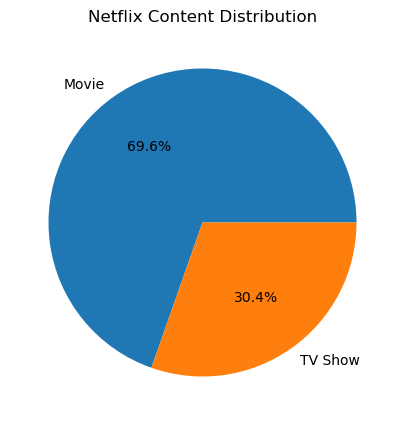

In [14]:
# Content type distribution using pie chart

type_counts = net_df['type'].value_counts()

plt.figure(figsize=(6,5))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%'
)

plt.title('Netflix Content Distribution')
plt.show()

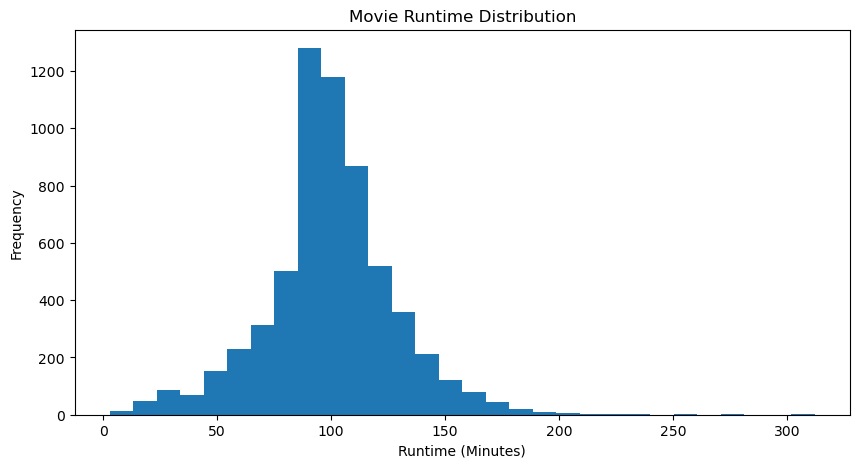

In [15]:
# Movies runtime distribution using histogram

movies = net_df[net_df['type'] == 'Movie']

plt.figure(figsize=(10,5))
plt.hist(movies['movie_runtime'].dropna(), bins=30)

plt.xlabel('Runtime (Minutes)')
plt.ylabel('Frequency')
plt.title('Movie Runtime Distribution')
plt.show()

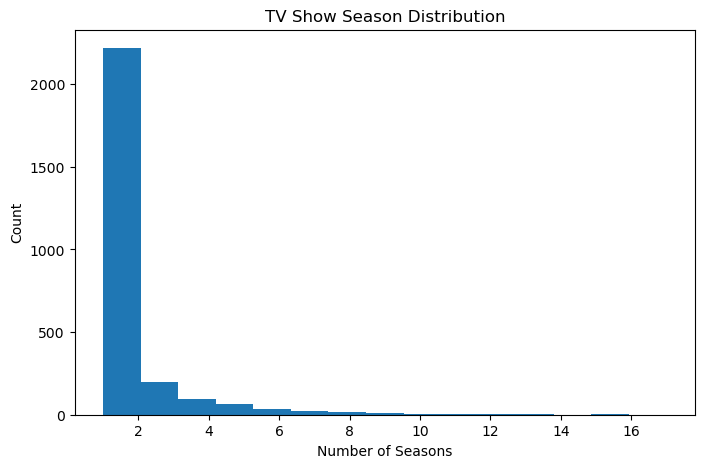

In [16]:
# TV show season distribution using Histogram

tv_shows = net_df[net_df['type'] == 'TV Show']

plt.figure(figsize=(8,5))
plt.hist(tv_shows['season_count'].dropna(), bins=15)

plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.title('TV Show Season Distribution')
plt.show()

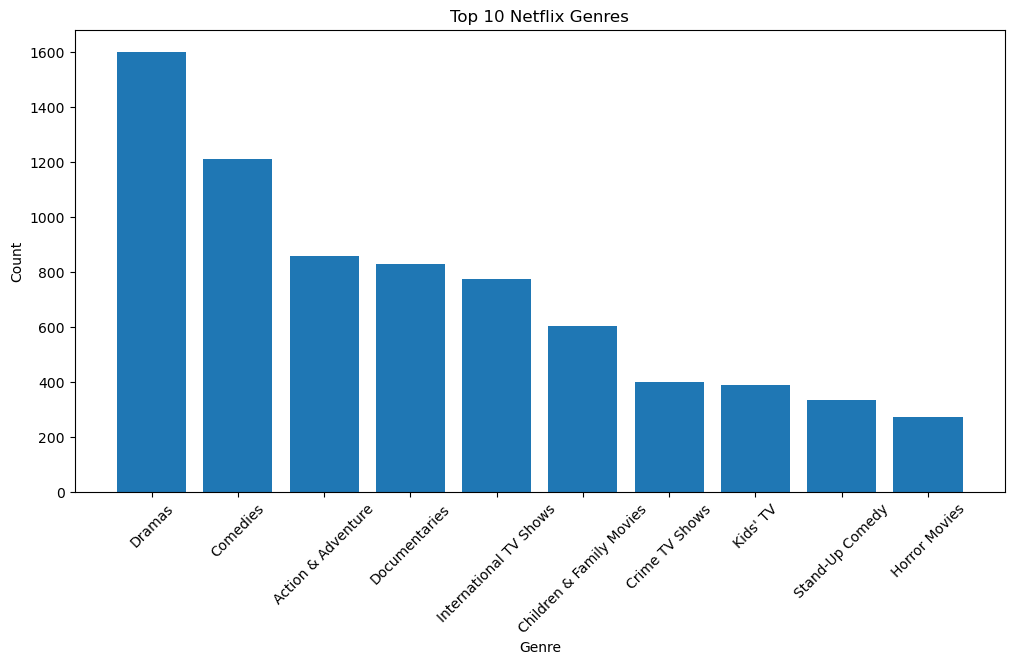

In [17]:
top_genres = net_df['primary_genre'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(top_genres.index, top_genres.values)

plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Netflix Genres')
plt.show()